BI Insight Visual generated successfully!


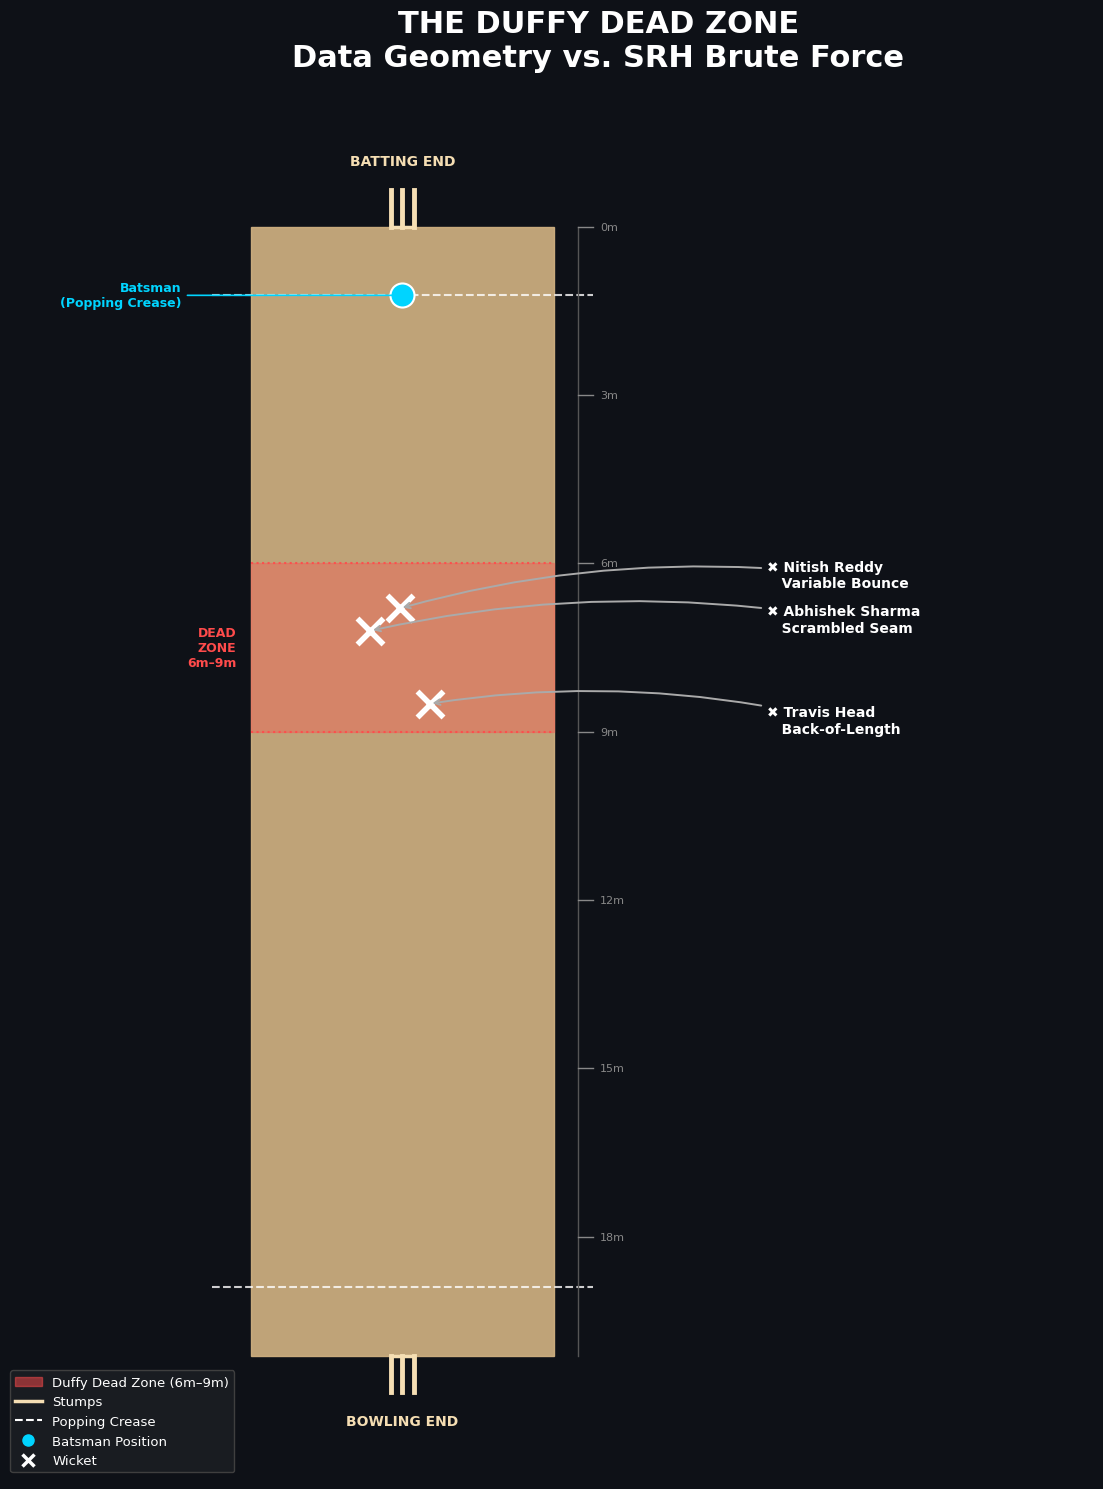

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.lines as mlines

def create_duffy_viz():
    fig, ax = plt.subplots(figsize=(11, 15), facecolor='#0E1117')
    ax.set_facecolor('#0E1117')

    pitch_width  = 3.05
    pitch_length = 20.12

    # --- Pitch Surface ---
    ax.add_patch(patches.Rectangle((0, 0), pitch_width, pitch_length,
                                   color='#D4B483', alpha=0.9, zorder=1))

    # --- Orientation ---
    # Batting END = TOP  (y = pitch_length = 20.12)
    # Bowling END = BOTTOM (y = 0)
    # Dead zone is 6–9 m from batting stumps  →  y = 20.12-9  to  20.12-6  =  11.12–14.12

    batting_stump_y  = pitch_length        # top
    bowling_stump_y  = 0.0                 # bottom
    popping_bat_y    = pitch_length - 1.22 # 18.90  (batsman stands here)
    popping_bowl_y   = 1.22                # bowler's popping crease

    dead_zone_top    = pitch_length - 6    # 14.12
    dead_zone_bottom = pitch_length - 9    # 11.12

    # --- Crease Lines ---
    for y in [popping_bat_y, popping_bowl_y]:
        ax.plot([-0.4, pitch_width + 0.4], [y, y],
                color='white', linewidth=1.5, linestyle='--', zorder=3, alpha=0.8)

    # --- Stumps ---
    stump_cx      = pitch_width / 2
    stump_offsets = [-0.114, 0.0, 0.114]
    stump_h       = 0.65

    # Batting end stumps (ABOVE pitch, at top)
    for dx in stump_offsets:
        ax.plot([stump_cx + dx, stump_cx + dx],
                [batting_stump_y, batting_stump_y + stump_h],
                color='#F5DEB3', linewidth=3.5, zorder=5)
    ax.plot([stump_cx + stump_offsets[0], stump_cx + stump_offsets[-1]],
            [batting_stump_y, batting_stump_y],
            color='#F5DEB3', linewidth=2.5, zorder=5)

    # Bowling end stumps (BELOW pitch, at bottom)
    for dx in stump_offsets:
        ax.plot([stump_cx + dx, stump_cx + dx],
                [-stump_h, bowling_stump_y],
                color='#F5DEB3', linewidth=3.5, zorder=5)
    ax.plot([stump_cx + stump_offsets[0], stump_cx + stump_offsets[-1]],
            [bowling_stump_y, bowling_stump_y],
            color='#F5DEB3', linewidth=2.5, zorder=5)

    # End labels
    ax.text(stump_cx, batting_stump_y + stump_h + 0.4, 'BATTING END',
            color='#F5DEB3', fontsize=10, fontweight='bold',
            ha='center', va='bottom', zorder=6)
    ax.text(stump_cx, -stump_h - 0.4, 'BOWLING END',
            color='#F5DEB3', fontsize=10, fontweight='bold',
            ha='center', va='top', zorder=6)

    # --- Batsman Position ---
    ax.scatter(stump_cx, popping_bat_y, color='#00D4FF', s=300, zorder=7,
               marker='o', edgecolors='white', linewidths=1.5)
    ax.annotate('Batsman\n(Popping Crease)', xy=(stump_cx, popping_bat_y),
                xytext=(-0.7, popping_bat_y),
                color='#00D4FF', fontsize=9, fontweight='bold',
                va='center', ha='right',
                arrowprops=dict(arrowstyle='->', color='#00D4FF', lw=1.2), zorder=8)

    # --- Dead Zone ---
    dead_h = dead_zone_top - dead_zone_bottom   # 3 m
    ax.add_patch(patches.Rectangle((0, dead_zone_bottom), pitch_width, dead_h,
                                   color='#FF4B4B', alpha=0.35, zorder=2))
    for y in [dead_zone_bottom, dead_zone_top]:
        ax.plot([0, pitch_width], [y, y],
                color='#FF4B4B', linewidth=1.5, linestyle=':', zorder=4, alpha=0.9)

    ax.text(-0.15, (dead_zone_bottom + dead_zone_top) / 2,
            'DEAD\nZONE\n6m–9m', color='#FF4B4B',
            fontsize=9, fontweight='bold', va='center', ha='right', zorder=6)

    # --- Distance ruler (measured from batting stumps, top downward) ---
    ruler_x = pitch_width + 0.25
    for dist in [0, 3, 6, 9, 12, 15, 18]:
        y_pos = pitch_length - dist
        ax.plot([ruler_x, ruler_x + 0.15], [y_pos, y_pos],
                color='#888888', linewidth=1, zorder=4)
        ax.text(ruler_x + 0.22, y_pos, f'{dist}m',
                color='#888888', fontsize=8, va='center', zorder=4)
    ax.plot([ruler_x, ruler_x], [0, pitch_length],
            color='#555555', linewidth=1, zorder=3)

    # --- Wicket Markers ---
    # y = pitch_length - distance_from_batting_stumps
    wickets = [
        {'name': 'Abhishek Sharma', 'x': 1.2,
         'y': pitch_length - 7.2, 'desc': 'Scrambled Seam'},
        {'name': 'Travis Head',     'x': 1.8,
         'y': pitch_length - 8.5, 'desc': 'Back-of-Length'},
        {'name': 'Nitish Reddy',    'x': 1.5,
         'y': pitch_length - 6.8, 'desc': 'Variable Bounce'},
    ]
    label_offsets = [
        (5.2, pitch_length - 7.0),
        (5.2, pitch_length - 8.8),
        (5.2, pitch_length - 6.2),
    ]

    for w, (lx, ly) in zip(wickets, label_offsets):
        ax.scatter(w['x'], w['y'], color='#FFFFFF', marker='x',
                   s=350, linewidths=4, zorder=6)
        ax.annotate(f"✖ {w['name']}\n   {w['desc']}",
                    xy=(w['x'], w['y']), xytext=(lx, ly),
                    color='white', fontsize=10, fontweight='bold',
                    va='center', ha='left',
                    arrowprops=dict(arrowstyle='->', color='#AAAAAA', lw=1.4,
                                   connectionstyle='arc3,rad=0.1'),
                    zorder=7)

    # --- Axes & Title ---
    ax.set_xlim(-1.5, 8.5)
    ax.set_ylim(-2.2, 22.5)
    ax.axis('off')

    plt.title("THE DUFFY DEAD ZONE\nData Geometry vs. SRH Brute Force",
              color='white', fontsize=22, fontweight='bold', pad=20)

    # --- Legend ---
    legend_handles = [
        patches.Patch(color='#FF4B4B', alpha=0.5, label='Duffy Dead Zone (6m–9m)'),
        mlines.Line2D([], [], color='#F5DEB3', linewidth=2.5, label='Stumps'),
        mlines.Line2D([], [], color='white', linewidth=1.5, linestyle='--',
                      label='Popping Crease'),
        mlines.Line2D([], [], color='#00D4FF', marker='o', linestyle='None',
                      markersize=8, label='Batsman Position'),
        mlines.Line2D([], [], color='white', marker='x', linestyle='None',
                      markersize=9, markeredgewidth=2.5, label='Wicket'),
    ]
    ax.legend(handles=legend_handles, loc='lower left',
              bbox_to_anchor=(-0.1, 0.0), facecolor='#1B1E23',
              edgecolor='#444444', labelcolor='white', fontsize=9.5,
              framealpha=0.9)

    plt.tight_layout()
    plt.savefig('duffy_viz_output.png', dpi=300, bbox_inches='tight')
    print("BI Insight Visual generated successfully!")

if __name__ == "__main__":
    create_duffy_viz()


Run Rate Surge visualization generated!


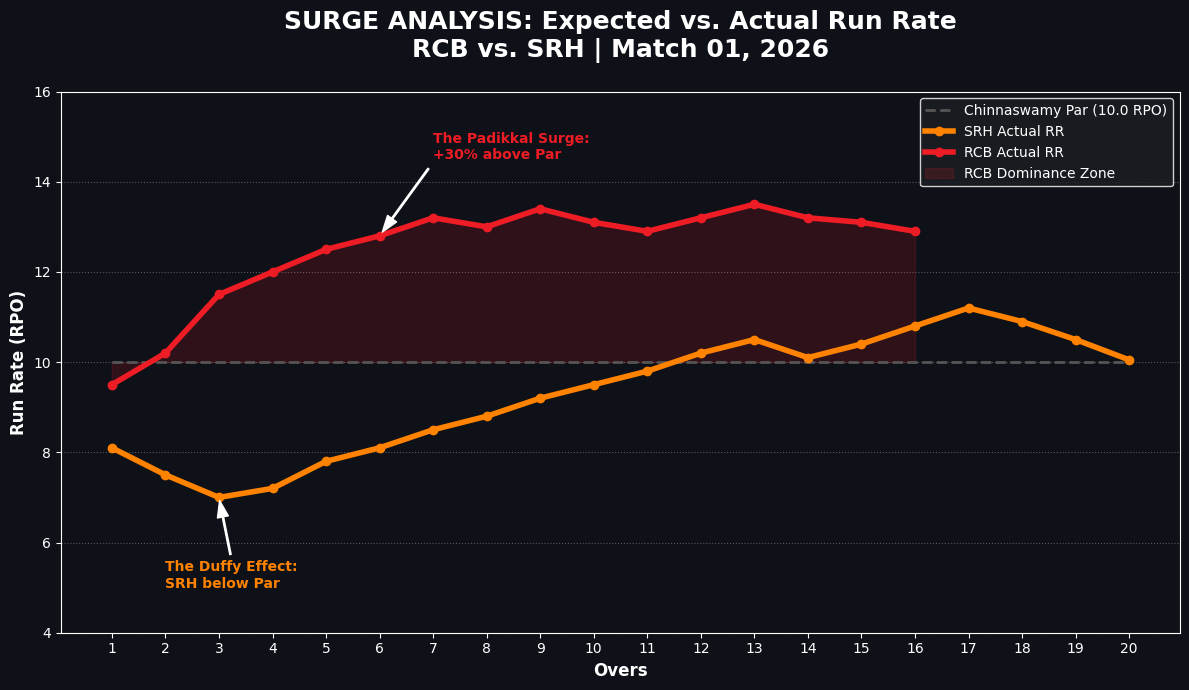

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def create_xrr_surge_viz():
    # 1. Setup - Premium BI Dark Theme
    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(12, 7), facecolor='#0E1117')
    ax.set_facecolor('#0E1117')

    # 2. Match Data (Overs 1-20)
    overs = np.arange(1, 21)
    
    # SRH Actual RR: Struggles in PP, peaks mid-innings with Kishan
    srh_rr = [8.1, 7.5, 7.0, 7.2, 7.8, 8.1, 8.5, 8.8, 9.2, 9.5, 9.8, 10.2, 10.5, 10.1, 10.4, 10.8, 11.2, 10.9, 10.5, 10.05]
    
    # RCB Actual RR: High start, sustained momentum (Match finished in 15.4 overs)
    rcb_overs = np.arange(1, 17)
    rcb_rr = [9.5, 10.2, 11.5, 12.0, 12.5, 12.8, 13.2, 13.0, 13.4, 13.1, 12.9, 13.2, 13.5, 13.2, 13.1, 12.9]

    # Chinnaswamy Baseline (10.0 RPO is the 'Par' for this venue)
    expected_rr = [10.0] * 20

    # 3. Plotting the Lines
    # The 'Par' baseline
    ax.plot(overs, expected_rr, color='#555555', linestyle='--', linewidth=2, label='Chinnaswamy Par (10.0 RPO)')

    # Team Actuals
    ax.plot(overs, srh_rr, color='#FF8200', linewidth=4, marker='o', label='SRH Actual RR')
    ax.plot(rcb_overs, rcb_rr, color='#EE1C25', linewidth=4, marker='o', label='RCB Actual RR')

    # 4. Highlight the 'Dominance Zone' (The Gap)
    ax.fill_between(rcb_overs, rcb_rr, expected_rr[:16], color='#EE1C25', alpha=0.15, label='RCB Dominance Zone')

    # 5. Technical Annotations
    ax.annotate('The Duffy Effect:\nSRH below Par', xy=(3, 7.0), xytext=(2, 5.0),
                arrowprops=dict(facecolor='white', shrink=0.05, width=1, headwidth=8),
                fontsize=10, color='#FF8200', fontweight='bold')

    ax.annotate('The Padikkal Surge:\n+30% above Par', xy=(6, 12.8), xytext=(7, 14.5),
                arrowprops=dict(facecolor='white', shrink=0.05, width=1, headwidth=8),
                fontsize=10, color='#EE1C25', fontweight='bold')

    # 6. Formatting for LinkedIn/Reels
    ax.set_xlabel('Overs', fontsize=12, fontweight='bold')
    ax.set_ylabel('Run Rate (RPO)', fontsize=12, fontweight='bold')
    ax.set_title('SURGE ANALYSIS: Expected vs. Actual Run Rate\nRCB vs. SRH | Match 01, 2026', 
                 fontsize=18, fontweight='bold', pad=25)
    
    ax.grid(axis='y', linestyle=':', alpha=0.3)
    plt.xticks(overs)
    plt.ylim(4, 16)
    
    # Legend Styling
    legend = plt.legend(loc='upper right', frameon=True, facecolor='#1B1E23', edgecolor='white')
    plt.setp(legend.get_texts(), color='white')

    plt.tight_layout()
    plt.savefig('rcb_srh_rr_surge.png', dpi=300)
    print("Run Rate Surge visualization generated!")

if __name__ == "__main__":
    create_xrr_surge_viz()